### Week 3 Task

#### Perform EDA(Exploratory Data Analysis):
* Identify correlations
* Find patterns in data
* Generate 5 insights

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df =pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Data Summary

In [68]:
# Basic info — column names, data types, non-empty counts
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

# Statistical summary — average, min, max, etc.
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

STATISTICAL SUMMARY


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Check for Missing values

In [85]:
# Finding Missing Values
print("Finding Missing values: ")
print(df.isnull().sum())


Finding Missing values: 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


### Checking For Duplicate Values

In [86]:
#Checking for duplicate value:
print('Duplicate Row:',df.duplicated().sum())

Duplicate Row: 0


### Identifying Correlation

* correlation is used to identify relationship between two or multiple variables
* correlation ranges from -1 to +1
* +1 - Strong Correlation
*  0 - No correlation
* -1 - Strong Negative Correlation

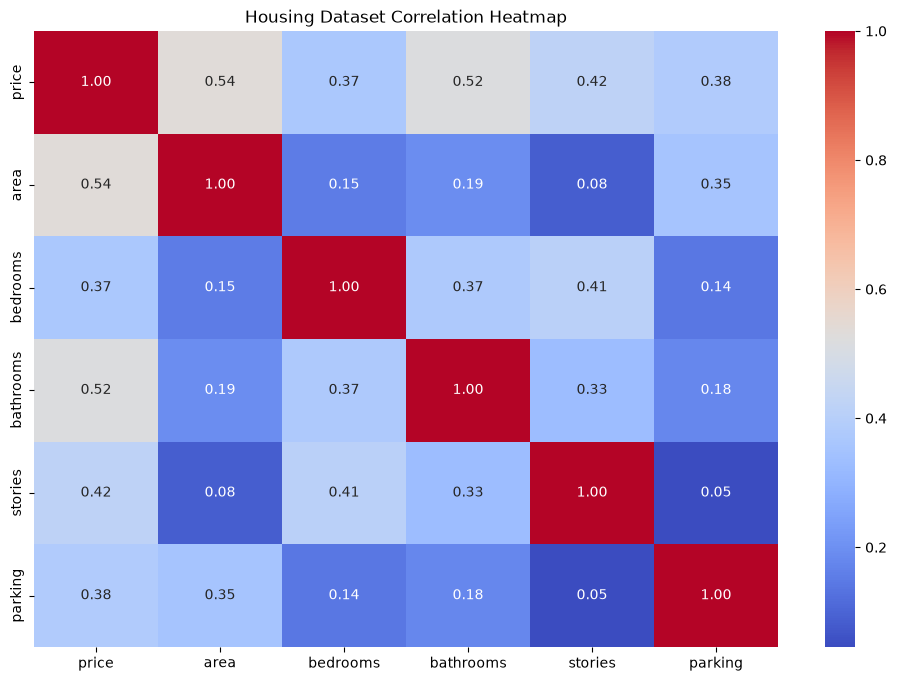

In [88]:
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation,
    annot=True,    #it will show the value inside the correlation map
    cmap='coolwarm',
    
    fmt='.2f'   #used for formatting values 
)
plt.title('Housing Dataset Correlation Heatmap')
plt.show()


### What the Heatmap Tells:
* Area has the strongest relationship with price (correlation 0.54) 
* Number of bathrooms (0.52) is almost as strongly linked to price as area
* Stories (0.42), parking (0.38), and bedrooms (0.37) all have moderate positive correlation with price 

### Patterns in data:

### Price vs Area

This chart helps determine whether larger houses tend to be more expensive.

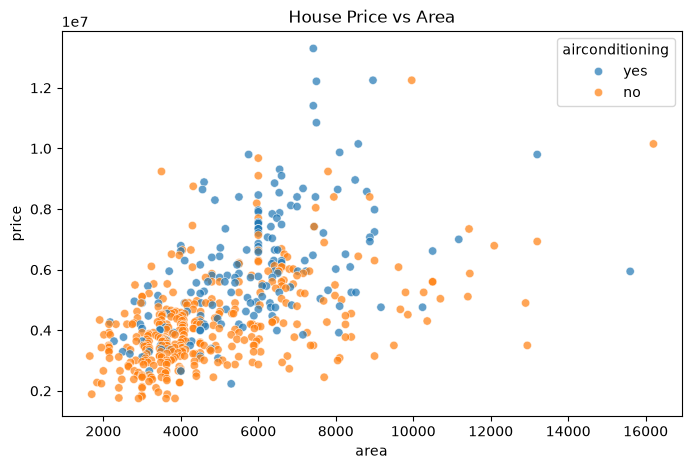

In [91]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="area",
    y="price",
    hue="airconditioning",
    alpha=0.7
)

plt.title("House Price vs Area")
plt.show()

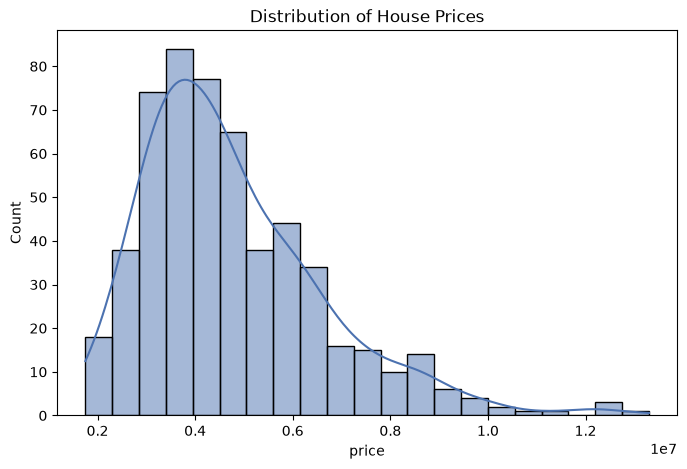

Median Price: 4340000.0
Mean Price: 4766729.247706422


In [92]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of House Prices")
plt.show()

print("Median Price:", df["price"].median())
print("Mean Price:", df["price"].mean())

### Price by Furnishing Status

Compare house prices across:
- Furnished
- Semi-Furnished
- Unfurnished

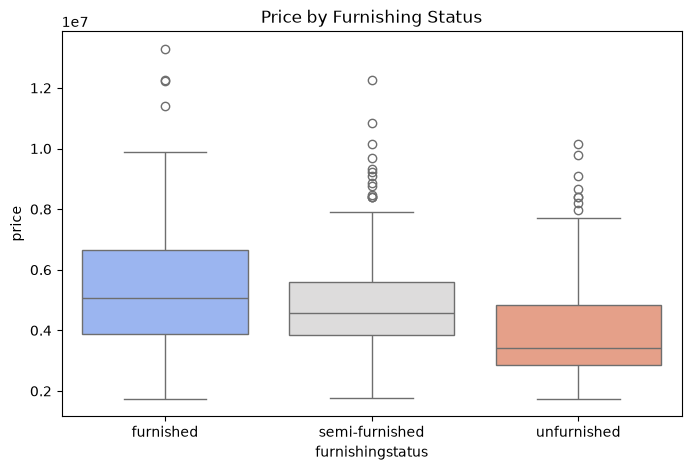

In [93]:
#Furnishing Status Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="furnishingstatus",
    y="price",
    hue="furnishingstatus",
    legend=False,
    palette="coolwarm"
)

plt.title("Price by Furnishing Status")
plt.show()

## Price Premium of Amenities

Calculates how much extra value each amenity adds to a house.

In [ ]:
amenities = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]


# Price Premium = Average Price (Amenity = Yes) -  Average Price (Amenity = No)

# Average price with AC      = 6,500,000
# Average price without AC   = 4,800,000

# Price Premium = 6,500,000 - 4,800,000 = 1,700,000

# Houses with air conditioning are, on average, ₹1.7 million more expensive than houses without air conditioning.



price_premium = [                      
    df[df[a] == "yes"]["price"].mean()
    - df[df[a] == "no"]["price"].mean()
    for a in amenities
]

for name, value in zip(amenities, price_premium):   #zip is funnction in python that combine two or more lists element by element
    print(f"{name}: {value:,.0f}")

mainroad: 1,592,873
guestroom: 1,248,351
basement: 732,649
hotwaterheating: 831,367
airconditioning: 1,821,281
prefarea: 1,453,747


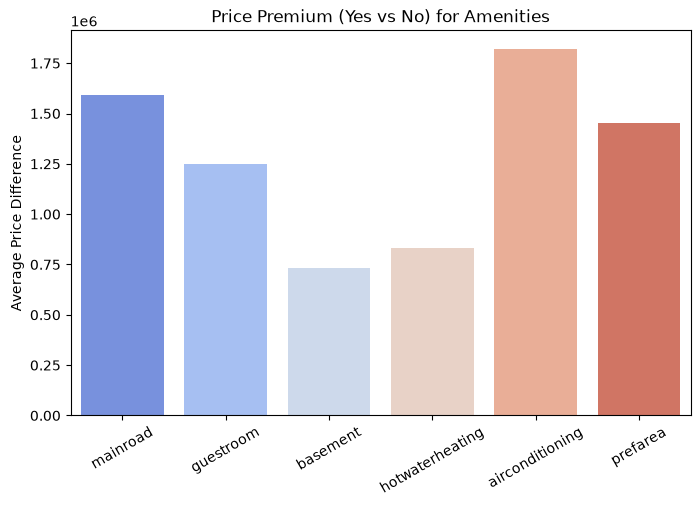

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=amenities,
    y=price_premium,
    hue=amenities,
    legend=False,
    palette="coolwarm"
)

plt.title("Price Premium (Yes vs No) for Amenities")
plt.ylabel("Average Price Difference")
plt.xticks(rotation=30)

plt.show()

### Generate 5 insights:

In [80]:
print("\n" + "=" * 14)
print("5 KEY INSIGHTS")
print("=" * 14)

print("1. Area is the strongest predictor of house price, with a")
print("   correlation of approximately 0.54, indicating that")
print("   larger properties generally have higher prices.")

print("2. Bathrooms influence price more than bedrooms.")
print("   Bathrooms (0.52) show a stronger relationship with")
print("   price than bedrooms (0.37).")

print("3. Air conditioning adds significant value to a property,")
print("   showing a relatively strong positive correlation")
print("   of about 0.45 with house price.")

print("4. Location impacts pricing. Houses in preferred areas")
print("   and those connected to the main road tend to have")
print("   higher market values.")

print("5. Unfurnished houses are generally cheaper, with a")
print("   negative correlation (-0.28) indicating lower prices")
print("   compared to furnished homes.")



5 KEY INSIGHTS
1. Area is the strongest predictor of house price, with a
   correlation of approximately 0.54, indicating that
   larger properties generally have higher prices.
2. Bathrooms influence price more than bedrooms.
   Bathrooms (0.52) show a stronger relationship with
   price than bedrooms (0.37).
3. Air conditioning adds significant value to a property,
   showing a relatively strong positive correlation
   of about 0.45 with house price.
4. Location impacts pricing. Houses in preferred areas
   and those connected to the main road tend to have
   higher market values.
5. Unfurnished houses are generally cheaper, with a
   negative correlation (-0.28) indicating lower prices
   compared to furnished homes.
